In [2]:
# SETTING UP 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Spyke Flores"
student_id   = "2025-0221"

id_num = int(student_id[-3:])
color1 = f"#{(id_num*7)%256:02x}{(id_num*3)%256:02x}{(id_num*5)%256:02x}"
color2 = f"#{(id_num*2)%256:02x}{(id_num*9)%256:02x}{(id_num*4)%256:02x}"

print(f"Student: {student_name} | ID: {student_id}")
print(f"Color 1: {color1} | Color 2: {color2}")

Student: Spyke Flores | ID: 2025-0221
Color 1: #0b9751 | Color 2: #bac574


In [3]:
# SETTING UP 2
dataset_path = r"C:\Users\Spyke\Downloads\archive\spotify_top_1000_tracks.csv"

df = pd.read_csv(dataset_path, encoding="utf-8")

# IMPORTANT: Check what columns you actually have
print("Columns:", df.columns.tolist())
print("\nShape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Columns: ['track_name', 'artist', 'album', 'release_date', 'popularity', 'spotify_url', 'id', 'duration_min']

Shape: (1000, 8)

First 3 rows:


,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667


In [4]:
# SETTING UP 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Spyke Flores"
student_id   = "2025-0221"

id_num = int(student_id[-3:])
color1 = f"#{(id_num*7)%256:02x}{(id_num*3)%256:02x}{(id_num*5)%256:02x}"
color2 = f"#{(id_num*2)%256:02x}{(id_num*9)%256:02x}{(id_num*4)%256:02x}"

dataset_path = r"C:\Users\Spyke\Downloads\archive\spotify_top_1000_tracks.csv"
df = pd.read_csv(dataset_path, encoding="utf-8")

df['track_name'] = df['track_name'].str.strip()
df['artist']     = df['artist'].str.strip()
df['album']      = df['album'].str.strip()

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']  = df['release_date'].dt.year
df['year']          = df['release_year']  # alias used in some plots

df['release_year'] = df['release_year'].fillna(0).astype(int)
df['year']         = df['year'].fillna(0).astype(int)

# Decade column — needed for many observation table items
df['decade'] = (df['release_year'] // 10) * 10

# Drop duplicates
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print("✅ Ready!")
print(f"Rows: {len(df)} | Columns: {df.columns.tolist()}")

✅ Ready!
Rows: 971 | Columns: ['track_name', 'artist', 'album', 'release_date', 'popularity', 'spotify_url', 'id', 'duration_min', 'release_year', 'year', 'decade']


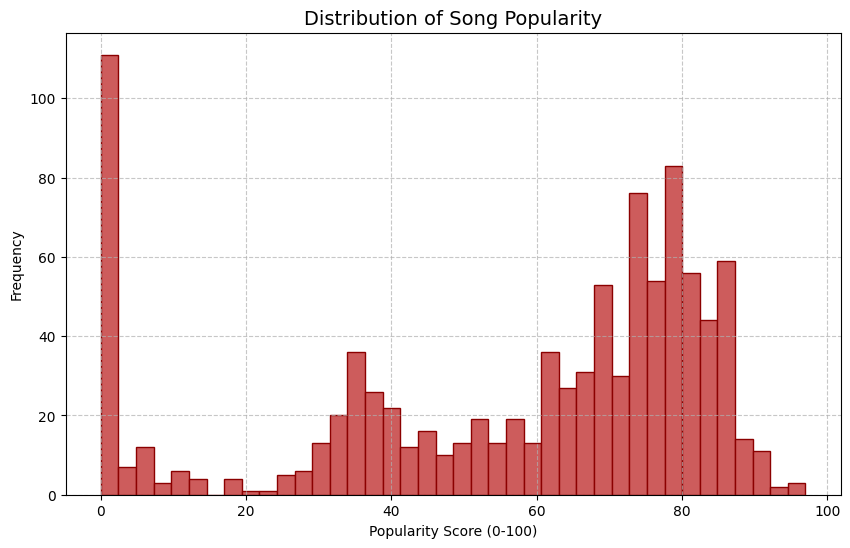

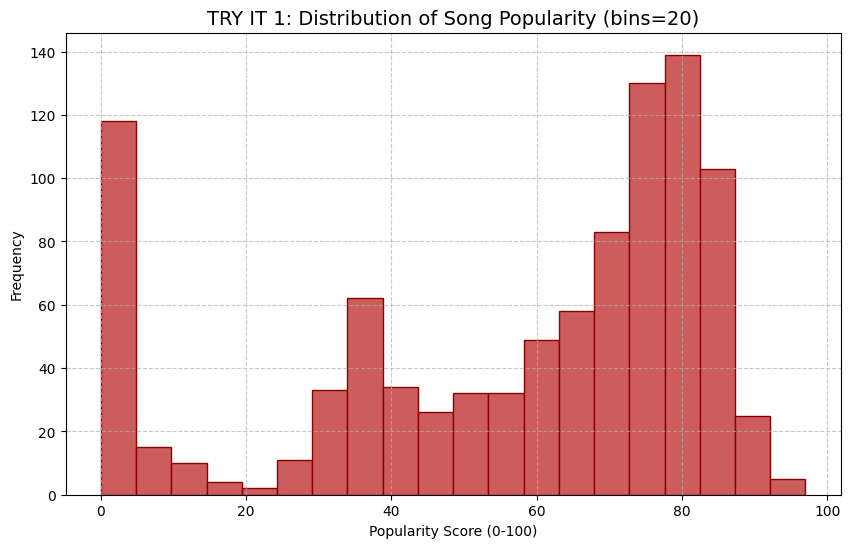

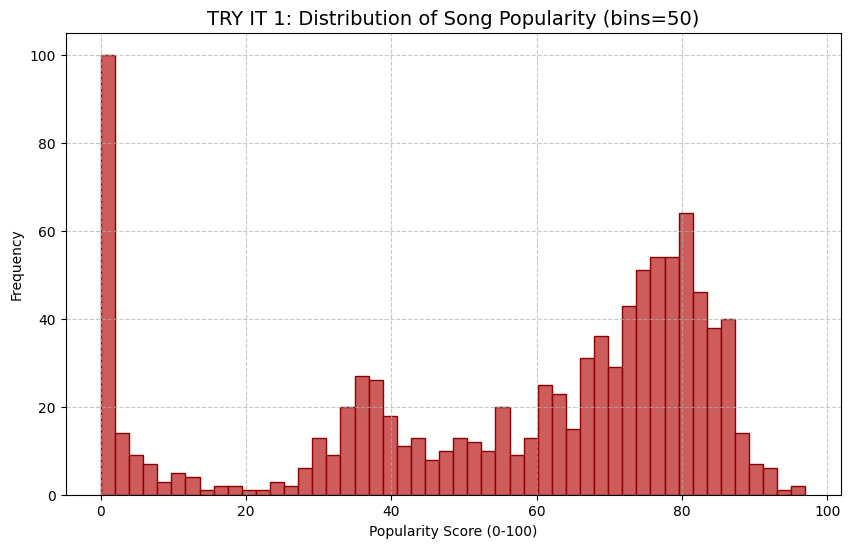

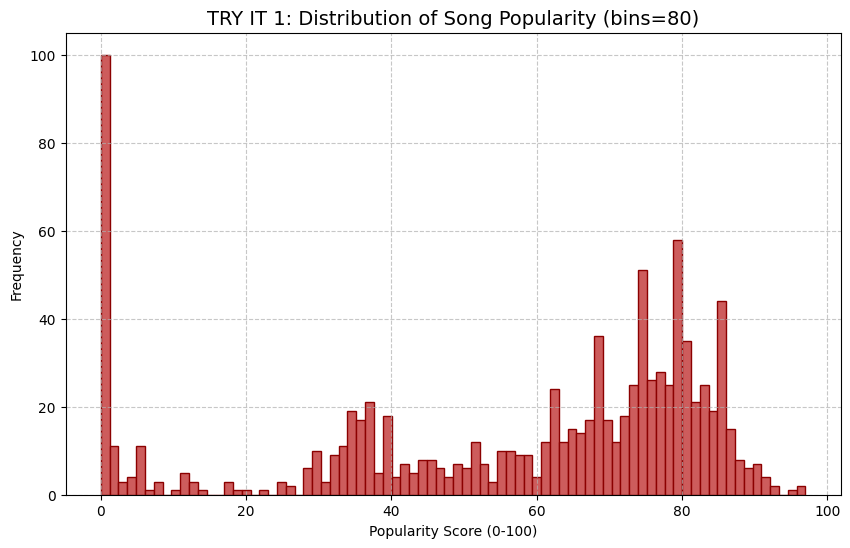

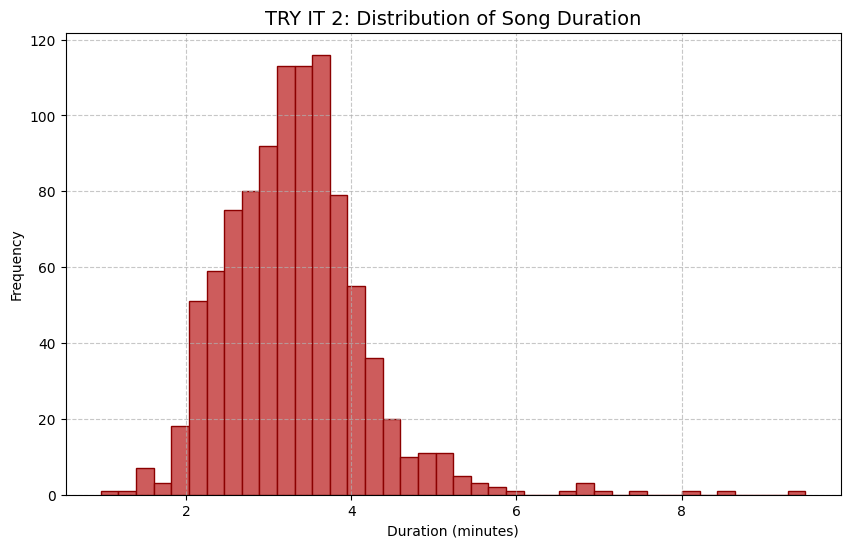

In [5]:
# PROCEDURE 1: Histogram

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=40, color='indianred', edgecolor='darkred')
plt.title('Distribution of Song Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# UPDATED: Try It 1
for bins in [20, 50, 80]:
    plt.figure(figsize=(10, 6))
    plt.hist(df['popularity'], bins=bins, color='indianred', edgecolor='darkred')
    plt.title(f'TRY IT 1: Distribution of Song Popularity (bins={bins})', fontsize=14)
    plt.xlabel('Popularity Score (0-100)')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# UPDATED: Try It 2
plt.figure(figsize=(10, 6))
plt.hist(df['duration_min'], bins=40, color='indianred', edgecolor='darkred')
plt.title('TRY IT 2: Distribution of Song Duration', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

C:\Users\Spyke\AppData\Local\Temp\ipykernel_8680\1151781579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='viridis')


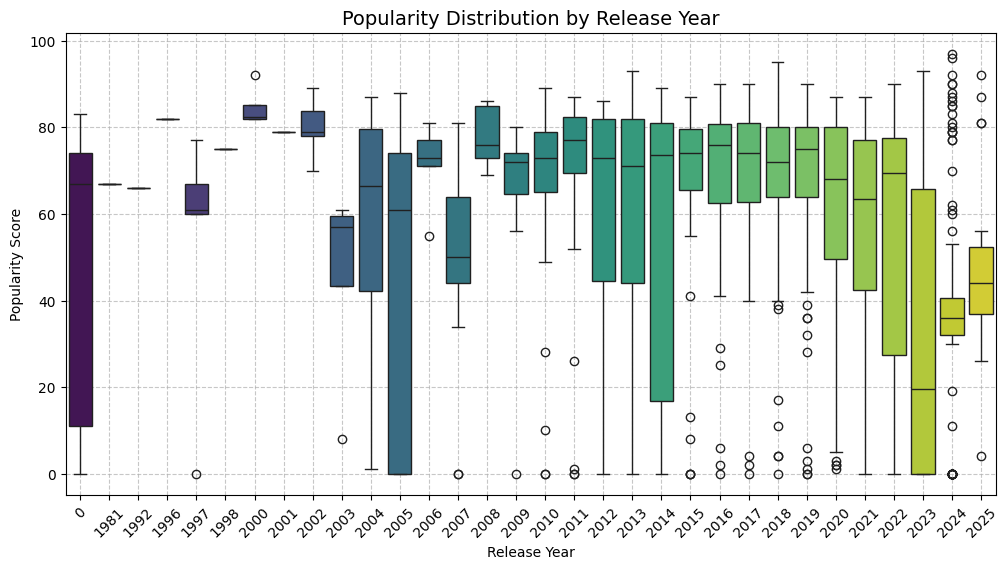

C:\Users\Spyke\AppData\Local\Temp\ipykernel_8680\1151781579.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette=palette)


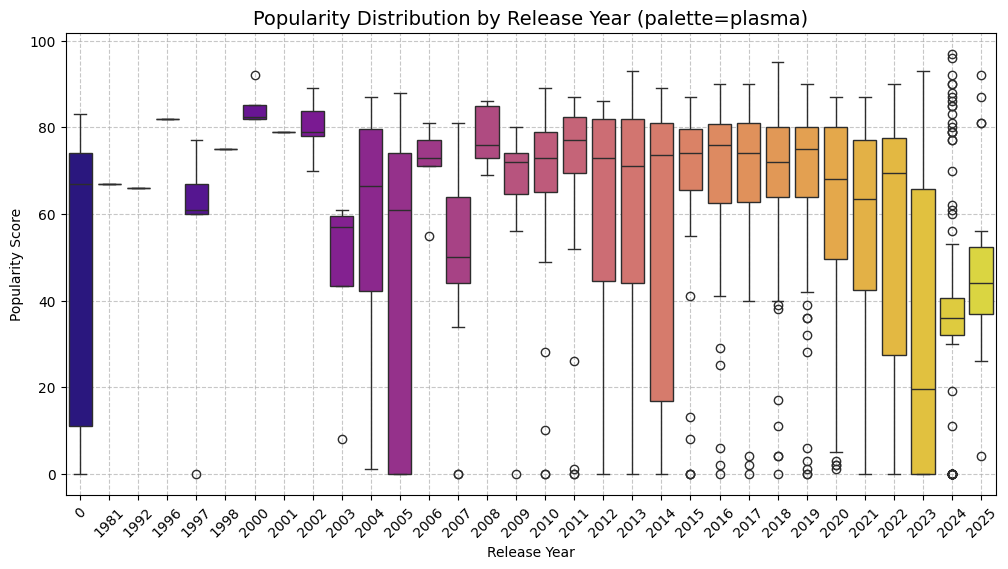

C:\Users\Spyke\AppData\Local\Temp\ipykernel_8680\1151781579.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette=palette)


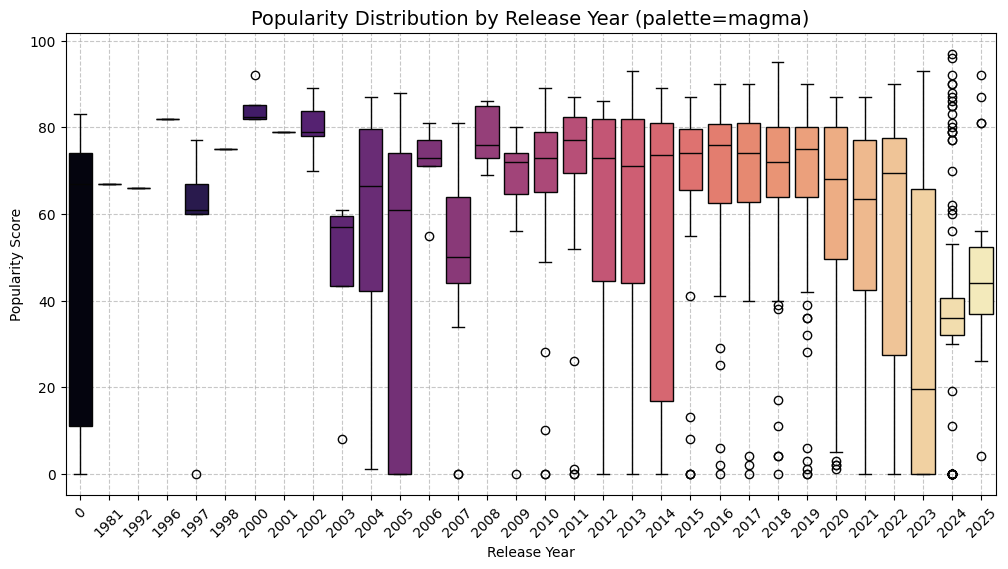

In [6]:
# PROCEDURE 2: Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='viridis')
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# UPDATED: Try It
for palette in ['plasma', 'magma']:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='year', y='popularity', data=df, palette=palette)
    plt.title(f'Popularity Distribution by Release Year (palette={palette})', fontsize=14)
    plt.xlabel('Release Year')
    plt.ylabel('Popularity Score')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

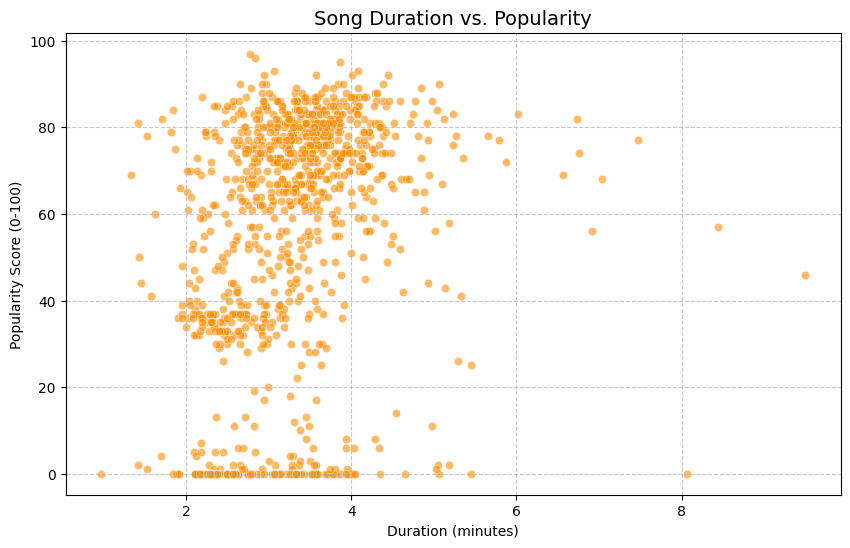

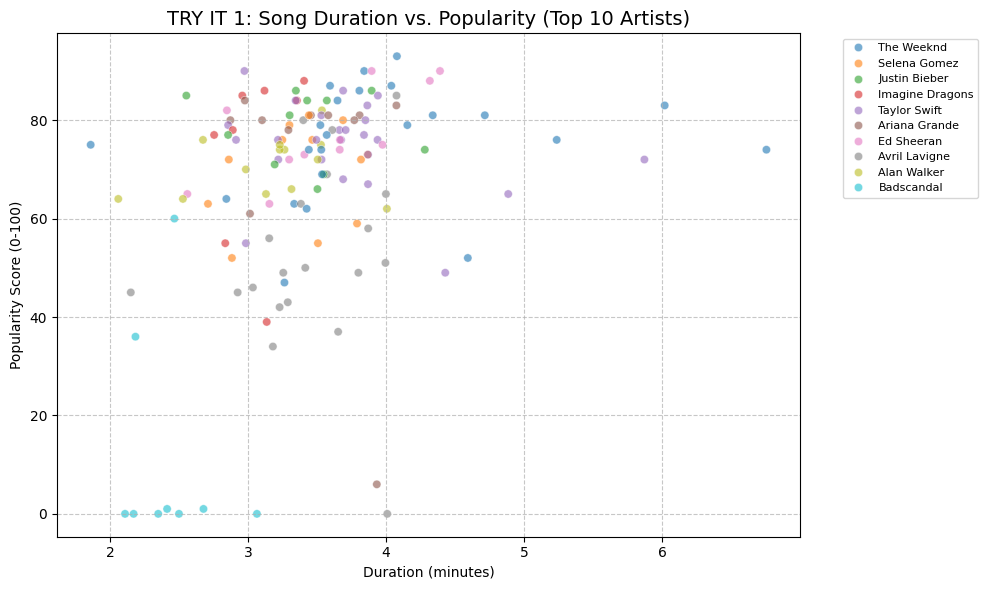

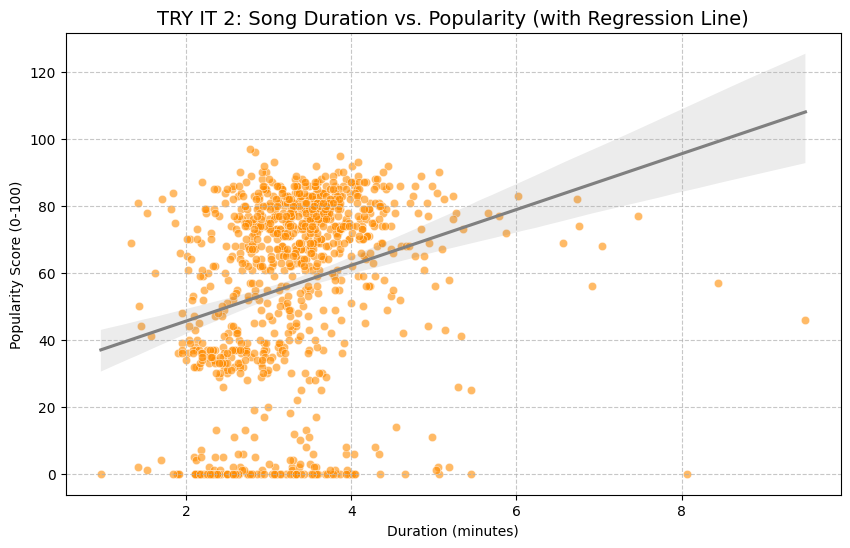

In [7]:
#  PROCEDURE 3: Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6, color='darkorange')
plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# UPDATED: Try It 1
top10_artists = df['artist'].value_counts().head(10).index
df_top10 = df[df['artist'].isin(top10_artists)]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df_top10, alpha=0.6, hue='artist')
plt.title('TRY IT 1: Song Duration vs. Popularity (Top 10 Artists)', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# UPDATED: Try It 2
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6, color='darkorange')
sns.regplot(x='duration_min', y='popularity', data=df, scatter=False, color='grey')
plt.title('TRY IT 2: Song Duration vs. Popularity (with Regression Line)', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

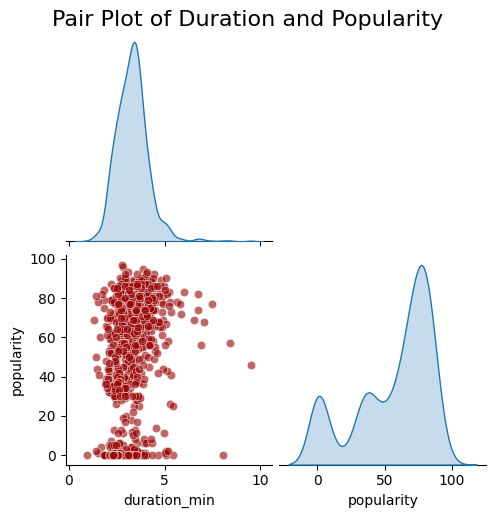

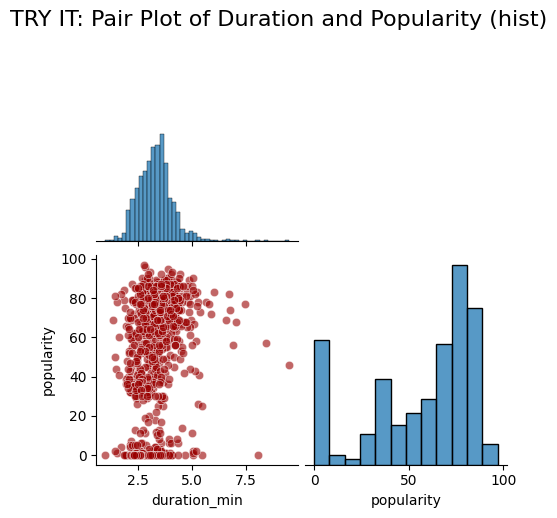

In [8]:
# PROCEDURE 4: Pair Plot
key_features = ['duration_min', 'popularity']
sns.pairplot(
    df[key_features],
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 'color': '#990000'}
)
plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16)
plt.show()

# UPDATED: Try It
key_features = ['duration_min', 'popularity']
sns.pairplot(
    df[key_features],
    diag_kind='hist',
    corner=True,
    plot_kws={'alpha': 0.6, 'color': '#990000'}
)
plt.suptitle('TRY IT: Pair Plot of Duration and Popularity (hist)', y=1.02, fontsize=16)
plt.show()

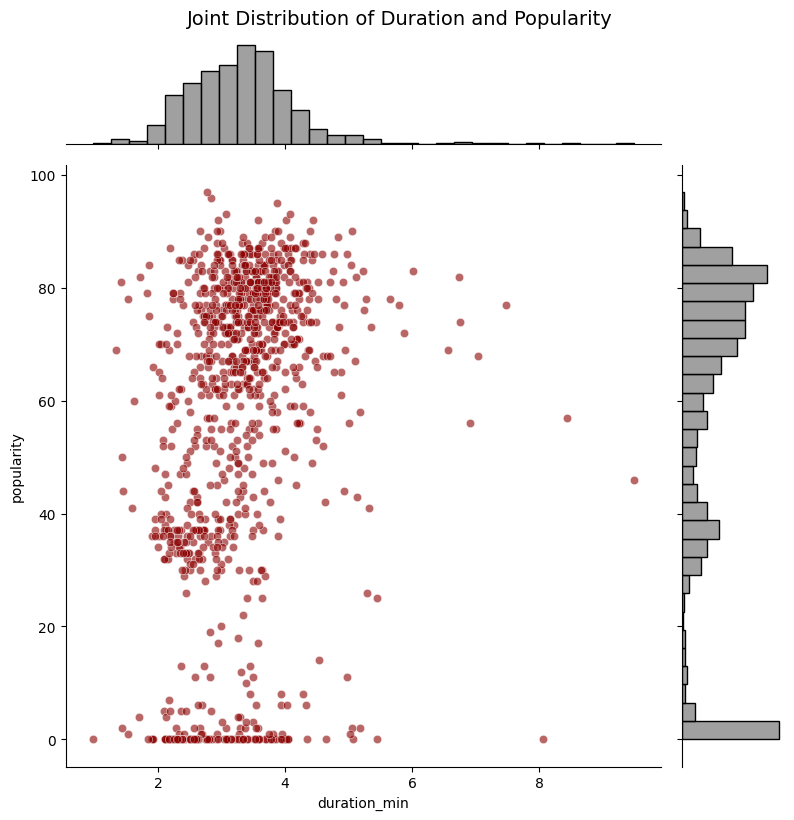

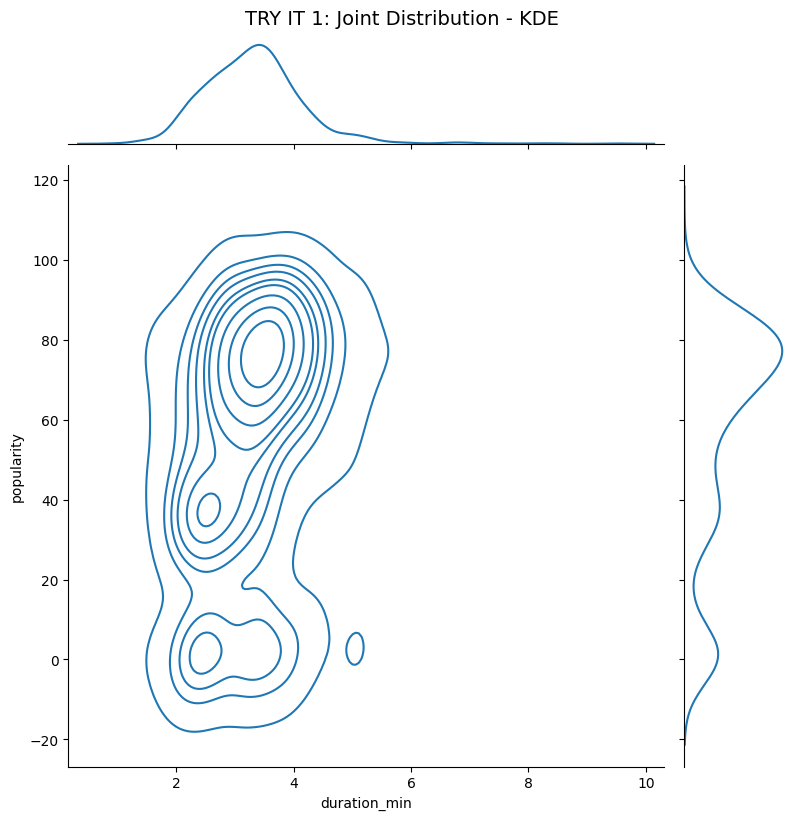

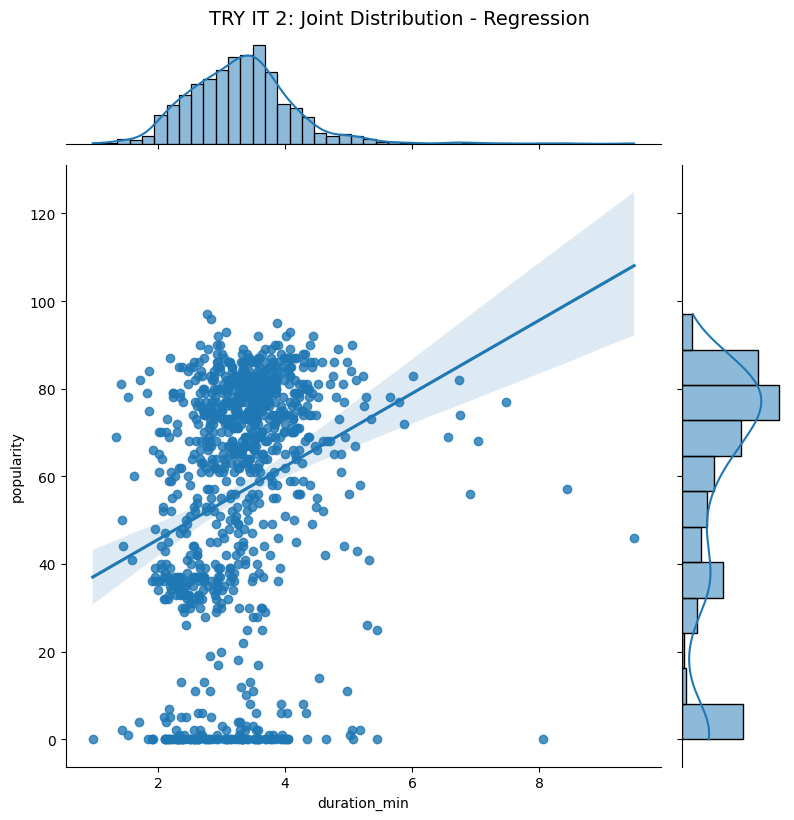

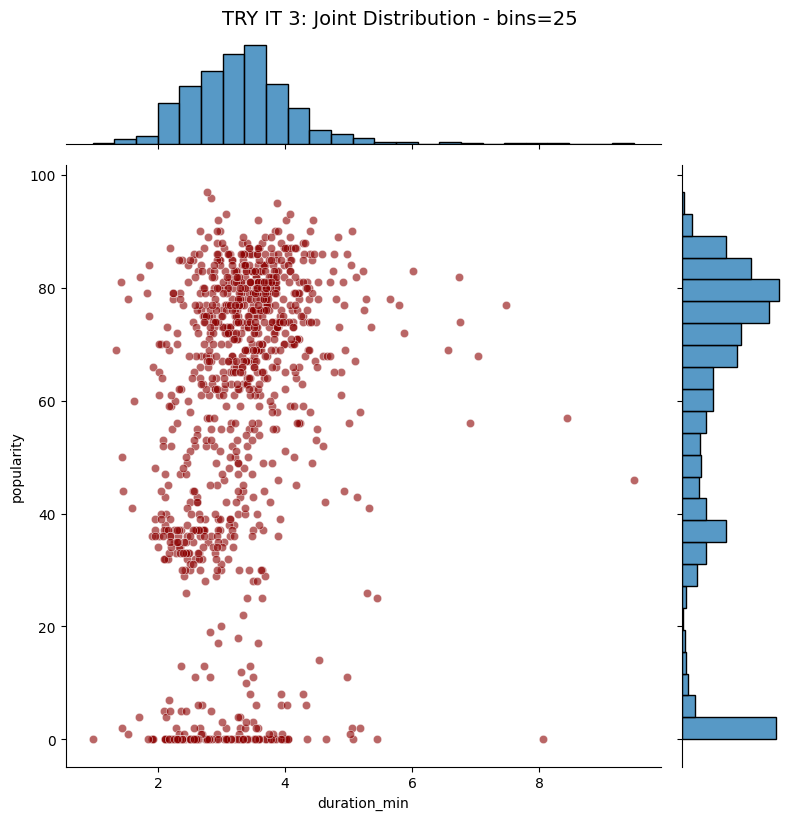

In [9]:
# PROCEDURE 5: Joint Plot
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='scatter',
    height=8,
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'},
    joint_kws={'alpha': 0.6, 'color': 'darkred'}
)
plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02, fontsize=14)
plt.show()

# UPDATED: Try It 1
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='kde',
    height=8,
)
plt.suptitle('TRY IT 1: Joint Distribution - KDE', y=1.02, fontsize=14)
plt.show()

# UPDATED: Try It 2
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='reg',
    height=8,
)
plt.suptitle('TRY IT 2: Joint Distribution - Regression', y=1.02, fontsize=14)
plt.show()

# UPDATED: Try It 3
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='scatter',
    height=8,
    marginal_kws=dict(bins=25),
    joint_kws={'alpha': 0.6, 'color': 'darkred'}
)
plt.suptitle('TRY IT 3: Joint Distribution - bins=25', y=1.02, fontsize=14)
plt.show()

In [10]:
# PROCEDURE 6: Animated Chart Line
import os
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

# --- Data Preparation ---
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df_anim = df.dropna(subset=['year'])

yearly_popularity = df_anim.groupby('year')['popularity'].mean().reset_index()
yearly_popularity = yearly_popularity.sort_values('year')

# --- Initialize Figure ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)
line, = ax.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')
ax.set_title("Evolution of Track Popularity Over Time", fontsize=14, color='navy')
ax.set_xlabel("Year of Release", fontsize=12)
ax.set_ylabel("Average Popularity", fontsize=12)
ax.legend(loc="upper left")
plt.tight_layout()

# --- Animation Function ---
def animate(i):
    x = yearly_popularity['year'][:i]
    y = yearly_popularity['popularity'][:i]
    line.set_data(x, y)
    return line,

# --- Save Animation ---
ani = FuncAnimation(fig, animate, frames=len(yearly_popularity), interval=100, repeat=False)
gif_path = os.path.abspath("yearly_popularity_trend.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))
print(f"✅ GIF saved at: {gif_path}")

# --- Open GIF ---
webbrowser.open(f"file://{gif_path}")
plt.close(fig)


# UPDATED: Try It
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax2.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)
line2, = ax2.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')
ax2.set_title("TRY IT: Evolution of Track Popularity Over Time (Fast)", fontsize=14, color='navy')
ax2.set_xlabel("Year of Release", fontsize=12)
ax2.set_ylabel("Average Popularity", fontsize=12)
ax2.legend(loc="upper left")
plt.tight_layout()

def animate2(i):
    x = yearly_popularity['year'][:i]
    y = yearly_popularity['popularity'][:i]
    line2.set_data(x, y)
    return line2,

ani2 = FuncAnimation(fig2, animate2, frames=len(yearly_popularity), interval=60, repeat=False)
gif_path2 = os.path.abspath("yearly_popularity_trend_fast.gif")
ani2.save(gif_path2, writer=PillowWriter(fps=10))
print(f"✅ Fast GIF saved at: {gif_path2}")
webbrowser.open(f"file://{gif_path2}")
plt.close(fig2)


✅ GIF saved at: c:\Users\Spyke\OneDrive\Documents\Lab7_DataVisualization_Flores\yearly_popularity_trend.gif
✅ Fast GIF saved at: c:\Users\Spyke\OneDrive\Documents\Lab7_DataVisualization_Flores\yearly_popularity_trend_fast.gif


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- YOUR INFO ---
student_name = "Spyke Flores"
student_id = "20250221"

id_num = int(student_id[-3:])
color1 = f"#{(id_num*7)%256:02x}{(id_num*3)%256:02x}{(id_num*5)%256:02x}"
color2 = f"#{(id_num*2)%256:02x}{(id_num*9)%256:02x}{(id_num*4)%256:02x}"

# --- Load Dataset ---
dataset_path = r"C:\Users\Spyke\Downloads\archive\spotify_top_1000_tracks.csv"  # ← your actual path

df = pd.read_csv(dataset_path, encoding="utf-8")
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)
df['year'] = df['release_year']
df['decade'] = (df['release_year'] // 10) * 10
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print("✅ Ready!", df.shape)

✅ Ready! (971, 11)


In [12]:
# DATA AND OBSERVATION 0
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Spyke Flores"
student_id = "20250221"

id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5)% 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4)% 256:02x}"

dataset_path = r"C:\Users\Spyke\Downloads\archive\spotify_top_1000_tracks.csv"

df = pd.read_csv(dataset_path, encoding="utf-8")
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)
df['year'] = df['release_year']
df['decade'] = (df['release_year'] // 10) * 10
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print(f"✅ Ready! | Color1: {color1} | Color2: {color2}")

✅ Ready! | Color1: #0b9751 | Color2: #bac574


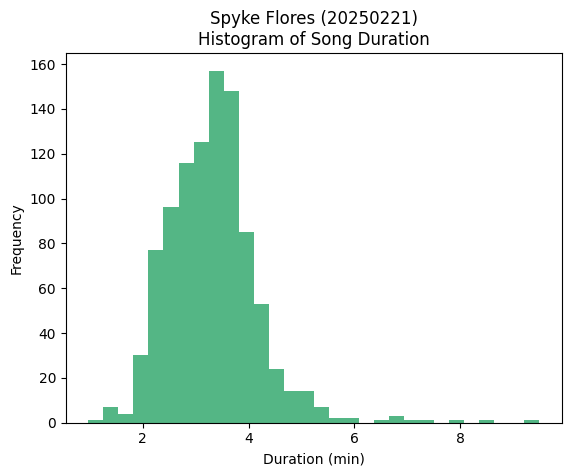

In [13]:
# DATA AND OBSERVATION 1
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()

C:\Users\Spyke\AppData\Local\Temp\ipykernel_8680\1034087801.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


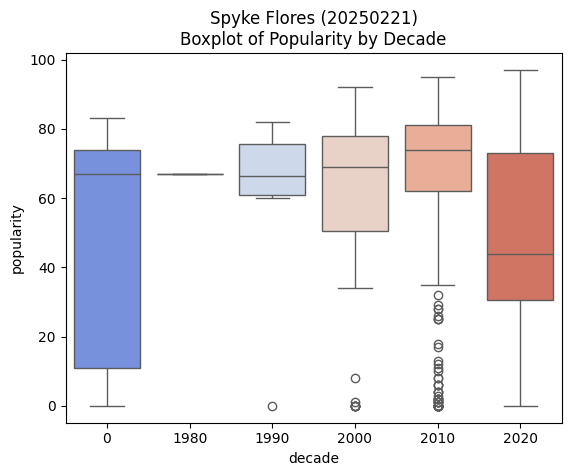

In [14]:
# DATA AND OBSERVATION 2
df['decade'] = (df['release_year'] // 10) * 10
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.show()

C:\Users\Spyke\AppData\Local\Temp\ipykernel_8680\1513226906.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df,


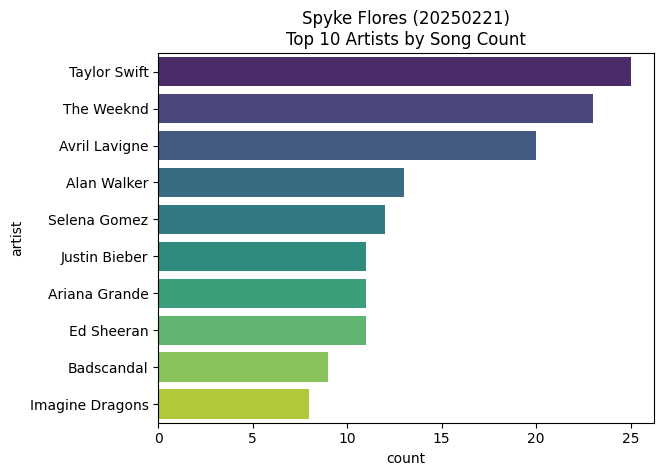

In [15]:
# DATA AND OBSERVATION 3
sns.countplot(y='artist', data=df,
order=df['artist'].value_counts().head(10).index, palette='viridis')
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.show()

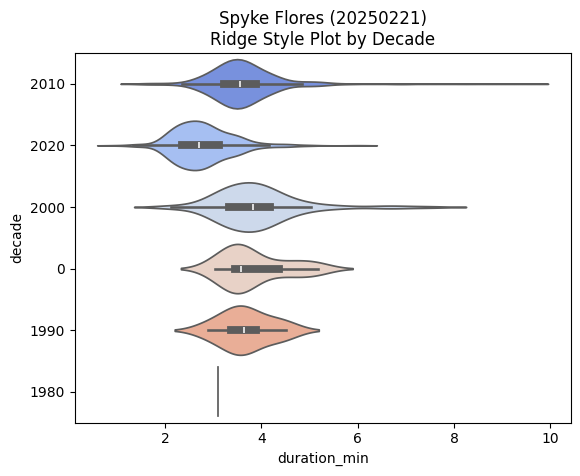

In [16]:
# DATA AND OBSERVATION 4
df['decade'] = df['decade'].astype(str)  # convert to string to reduce computation

sns.violinplot(data=df, x='duration_min', y='decade', 
               hue='decade', palette='coolwarm', 
               density_norm='width', legend=False)
plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.show()

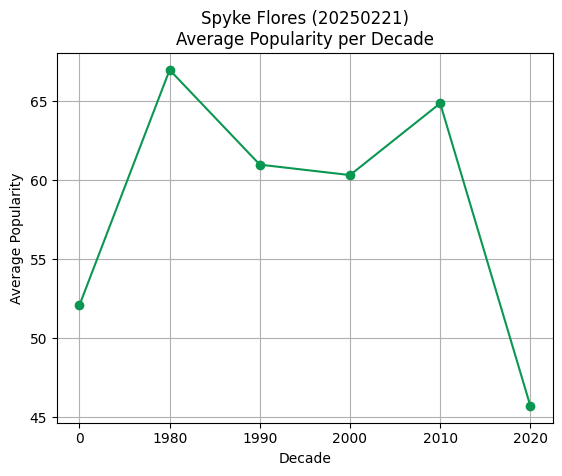

In [17]:
# DATA AND OBSERVATION 5
avg_pop = df.groupby('decade')['popularity'].mean()
avg_pop.plot(kind='line', color=color1, marker='o')
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.show()

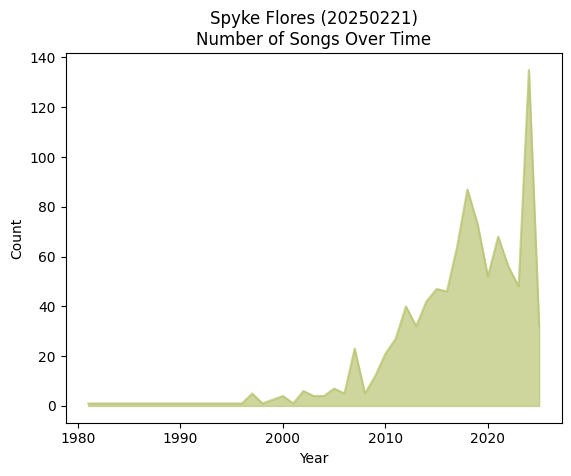

In [18]:
# DATA AND OBSERVATION 6
df['release_year'] = pd.to_datetime(df['release_date'],
errors='coerce').dt.year
count_by_year = df['release_year'].value_counts().sort_index()
count_by_year.plot(kind='area', color=color2, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


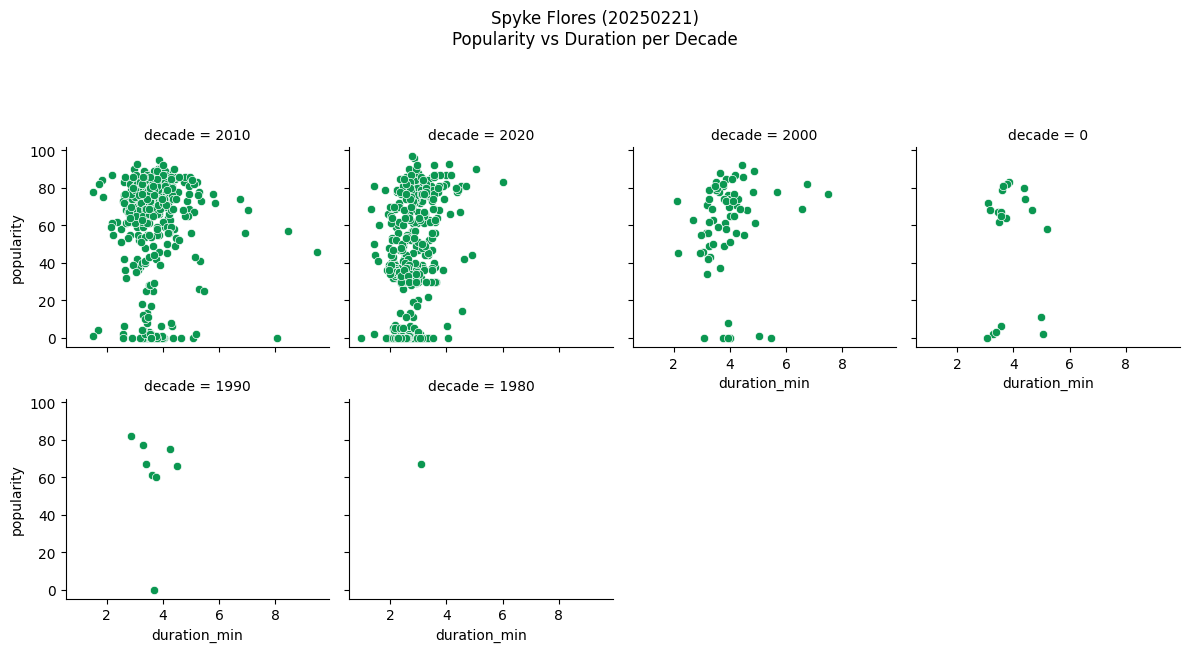

In [19]:
# DATA AND OBSERVATION 7
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity',
color=color1)
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.08)
g.fig.subplots_adjust(top=0.85)
plt.show()

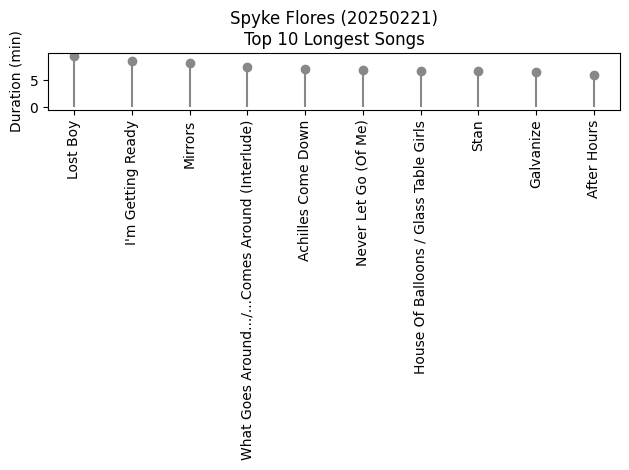

In [20]:
# DATA AND OBSERVATION 8
longest = df.nlargest(10, 'duration_min')
plt.stem(longest['track_name'], longest['duration_min'],
linefmt='#888888', markerfmt='o', basefmt=" ")
plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()


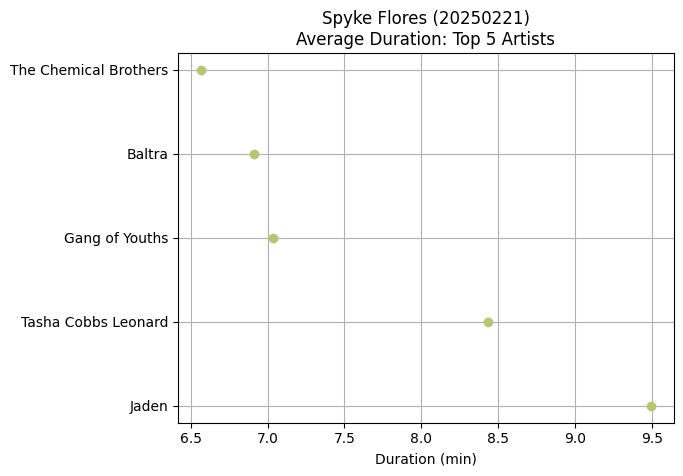

In [21]:
# DATA AND OBSERVATION 9
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2)
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists")
plt.xlabel('Duration (min)')
plt.grid(True)
plt.show()

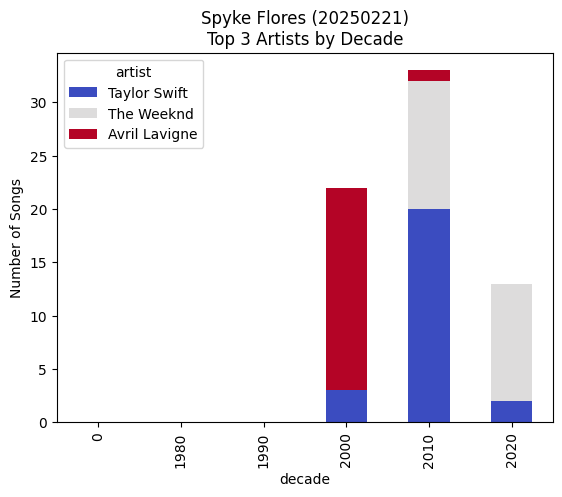

In [22]:
# DATA AND OBSERVATION 10
crosstab = pd.crosstab(df['decade'], df['artist'])
top3 = df['artist'].value_counts().head(3).index
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.show()

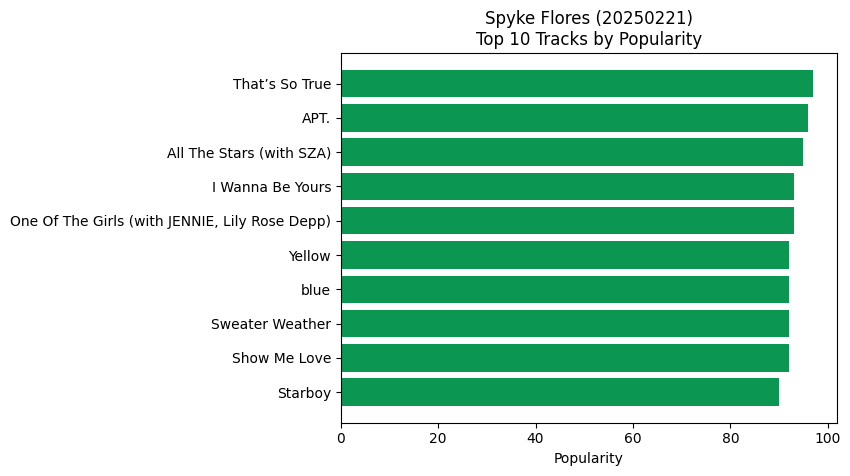

In [23]:
# DATA AND OBSERVATION 11
top_tracks = df.nlargest(10, 'popularity')
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1)
plt.xlabel('Popularity')
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")
plt.gca().invert_yaxis()
plt.show()
     

C:\Users\Spyke\AppData\Local\Temp\ipykernel_8680\3864150899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=['#8C1515', '#888888'])
C:\Users\Spyke\AppData\Local\Temp\ipykernel_8680\3864150899.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=['#8C1515', '#888888'])


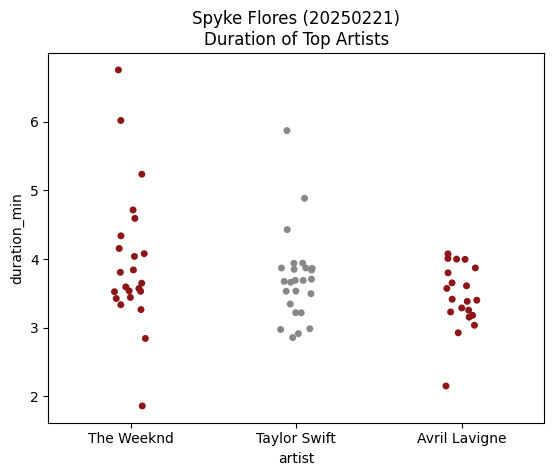

In [24]:
# DATA AND OBSERVATION 12
top_artists = df['artist'].value_counts().head(3).index
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=['#8C1515', '#888888'])
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists")
plt.show()

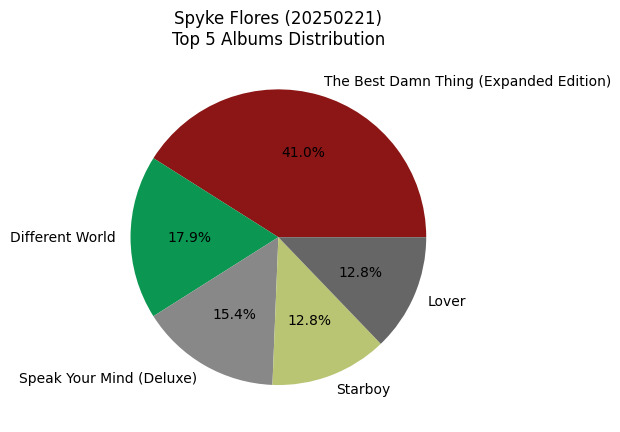

In [25]:
# DATA AND OBSERVATION 13
top_albums = df['album'].value_counts().head(5)
colors = ['#8C1515', color1, '#888888', color2, '#666666']
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', colors=colors)
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
plt.show()

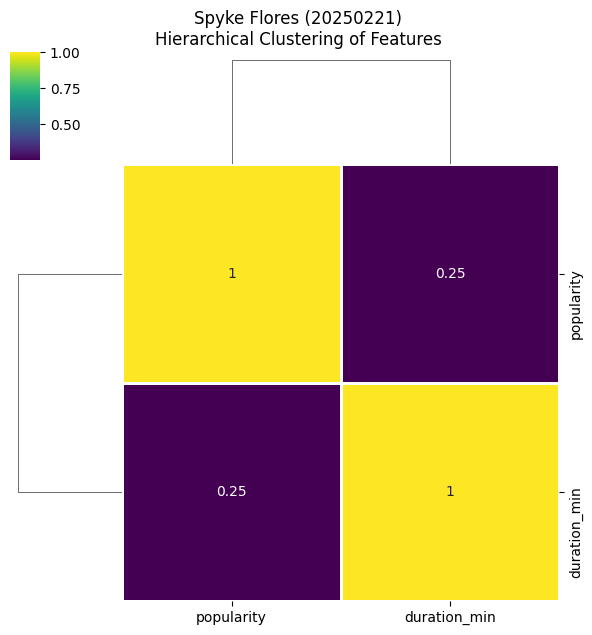

In [26]:
# DATA AND OBSERVATION 14
numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()
g = sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis', linewidths=.75, figsize=(6, 6))
g.fig.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features", y=1.05)
plt.show()

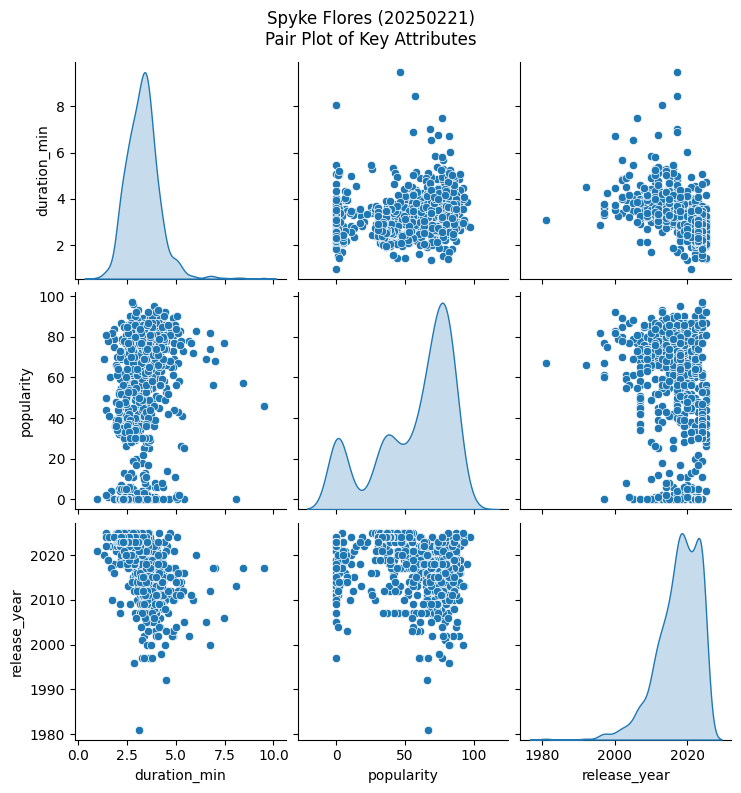

In [27]:
# DATA AND OBSERVATION 15
sns.pairplot(df[['duration_min', 'popularity', 'release_year']], diag_kind='kde')
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.05)
plt.show()

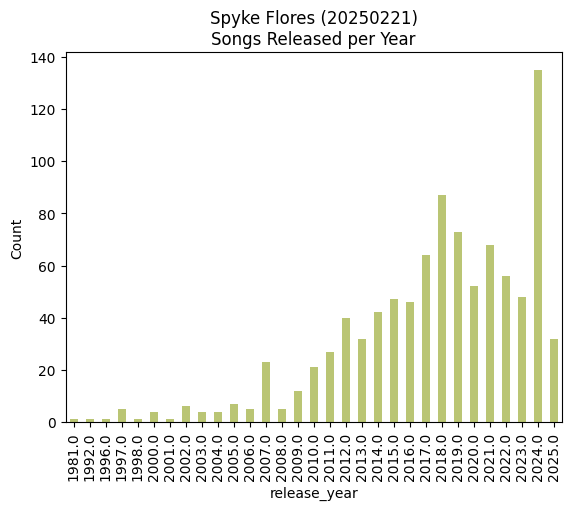

In [28]:
# DATA AND OBSERVATION 16
df['release_year'].value_counts().sort_index().plot(kind='bar', color=color2)
plt.title(f"{student_name} ({student_id})\nSongs Released per Year")
plt.ylabel('Count')
plt.show()

C:\Users\Spyke\AppData\Local\Temp\ipykernel_8680\1242072.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')


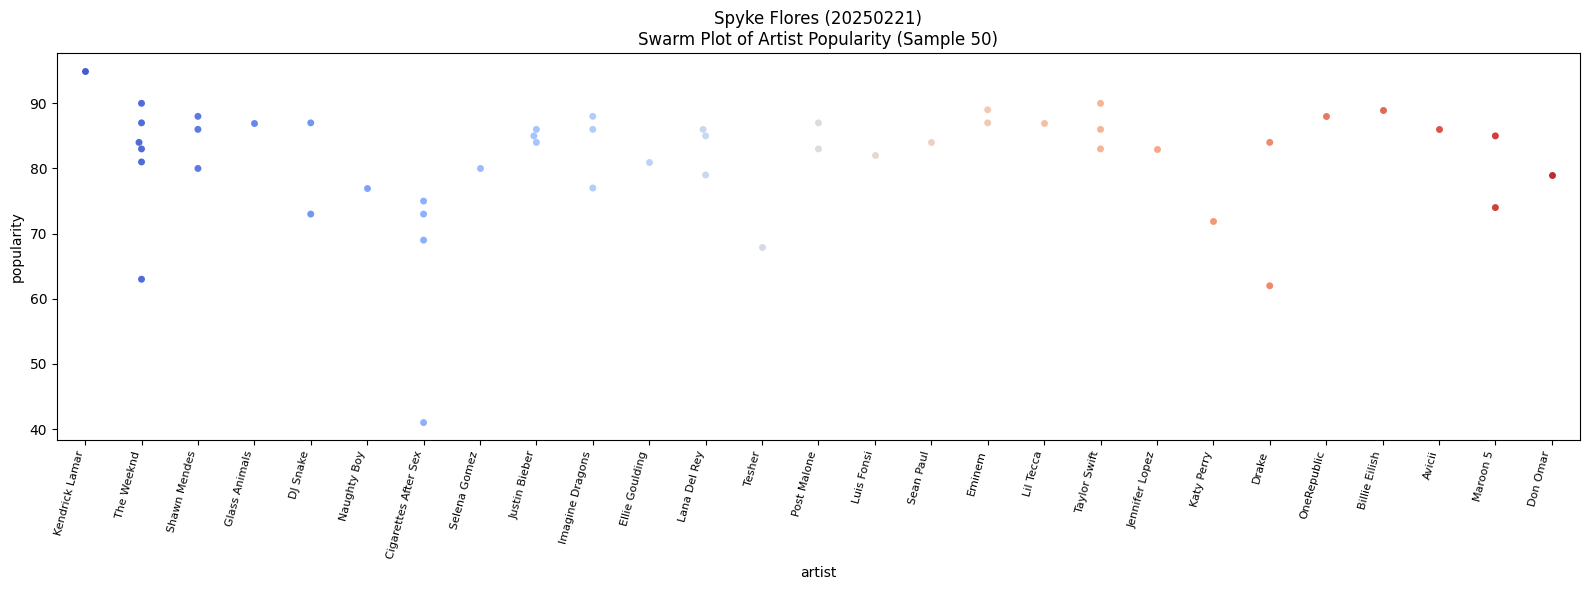

In [29]:
# DATA AND OBSERVATION 17
# Item 17 - Swarm Plot
plt.figure(figsize=(16, 6))  # wider figure
sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)")
plt.xticks(rotation=75, ha='right', fontsize=8)  # more rotation + smaller font
plt.tight_layout()
plt.show()

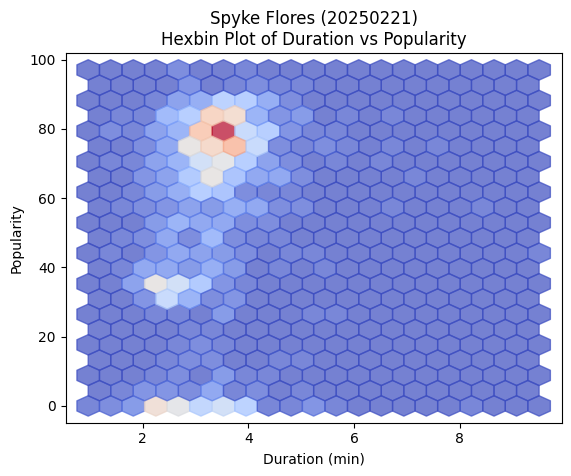

In [30]:
# DATA AND OBSERVATION 18
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, cmap='coolwarm', alpha=0.7)
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")
plt.show()

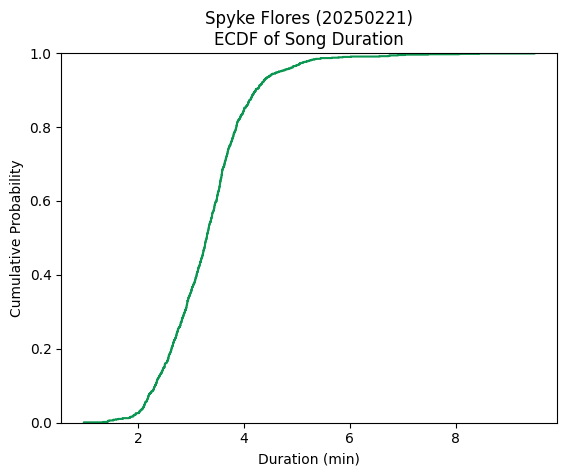

In [31]:
# DATA AND OBSERVATION 19
sns.ecdfplot(data=df, x='duration_min', color=color1)
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Cumulative Probability')
plt.show()

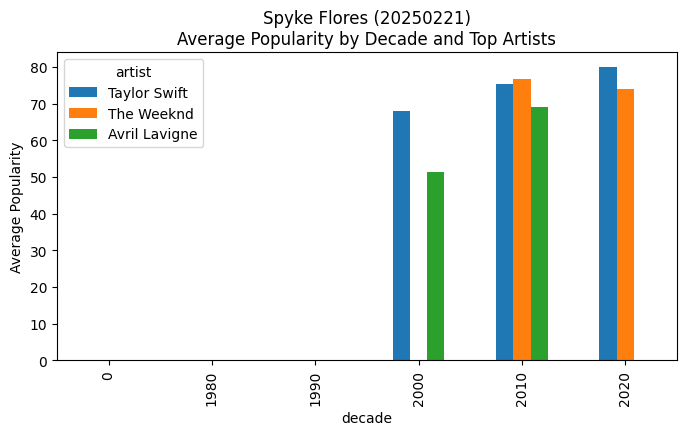

In [32]:

# DATA AND OBSERVATION 20
avg_artist_decade = df.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0)
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4))
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists")
plt.ylabel('Average Popularity')
plt.show()